# Value Based Segmentation for Amazing International Airlines Inc
## Data Mining Project
------
**Group 12:**

- Luis Mendes 20221949
- Margarida Mourives 20221809
- Simon Sazonov 20221689 
- Veronica Mendes 20221945

----
# Exploratory Data Analysis (EDA) 
## Summary

Value-based segmentation, grouping customers according to their economic contribution.

<a class="anchor" id='toc'></a> 
<div class="alert alert-block alert-info">

## **Index**<br>

[**Imports**](#0-bullet)<br>

[**Metadata**](#1-bullet)<br>

[**Data Preprocessing**](#1st-bullet)<br>
- [**Inconcistances**](#2nd-bullet)<br>
- [**Outliers**](#2nd-bullet)<br>
- [**Scaling**](#1st-bullet)<br>
    - [Robust Scaler](#3rd-bullet)<br>

[**Clustering**](#1st-bullet)<br>
- [**KNN**](#2nd-bullet)<br>
- [**KNN**](#2nd-bullet)<br>

    
</div>

<a class="anchor" id="0-bullet">    </a>
# Imports
[Back to Index](#toc)

In [603]:

# Standard library imports
import os
import warnings
from math import ceil

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler, MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    confusion_matrix,
    classification_report,
    accuracy_score,
)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import umap

# Local application imports
from utils_clustering import (
    visualize_dimensionality_reduction,
    plot_comparing_avr_clusters,
    plot_dendrogram,
)

# Configuration
RANDOM_STATE = 42
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

sns.set_context("notebook")
sns.set_style("ticks")


In [604]:
MasterCustomerDB_Complete = pd.read_csv('../../data/DM_AIAI_MasterCustomerDB.csv')
MasterCustomerDB = MasterCustomerDB_Complete.copy()

In [605]:
cols_to_keep = [
    'Loyalty#',
    'Customer Lifetime Value',
    'Days_with_us',
    'Days_until_reengagement',
    'Total_NumFlights',
    'Total_DistanceKM',
    'Perc_Flights_With_Companions',
    'Dollar_Cost_Points_Remaining',
    'Recency_Days'
]

Value_Based_Segmentation_clustering = MasterCustomerDB[cols_to_keep].copy()
Value_Based_Segmentation_clustering = Value_Based_Segmentation_clustering.set_index('Loyalty#')

<a class="anchor" id="value-based-segmentation">    </a>
### Metadata – Value-Based Segmentation
[Back to Index](#toc)

**Preprocessed & Merged Dataset**

*This dataset is derived from the integration and transformation of `DM_AIAI_CustomerDB.csv` and `DM_AIAI_FlightsDB.csv`.  
It contains engineered features designed to support value-based customer segmentation, focusing on customer profitability, loyalty behavior, and engagement over time.*

### Variables

- *Customer Lifetime Value* – Total estimated monetary value generated by the customer over the duration of the relationship

- *Days_with_us* – Total number of days the customer has been active in the loyalty program since enrollment

- *Days_until_reengagement* – Number of days between cancellation and re-engagement for returning customers

- *Total_NumFlights* – Total number of flights taken by the customer during the observed period

- *Total_DistanceKM* – Total cumulative flight distance traveled by the customer in kilometers

- *Perc_Flights_With_Companions* – Percentage of flights taken with companions relative to the customer’s total flights

- *Dollar_Cost_Points_Remaining* – Estimated dollar value of loyalty points accumulated but not yet redeemed by the customer

- *Recency_Days* – Number of days since the customer’s most recent flight activity


# Preprocessing

Lets explore our EDA data set on NA and negativenumbers

In [606]:
Value_Based_Segmentation_clustering.isna().sum()


Customer Lifetime Value             0
Days_with_us                        0
Days_until_reengagement         16373
Total_NumFlights                 1471
Total_DistanceKM                 1471
Perc_Flights_With_Companions     1471
Dollar_Cost_Points_Remaining     1471
Recency_Days                     1471
dtype: int64

In [607]:
(Value_Based_Segmentation_clustering < 0).sum()

Customer Lifetime Value           0
Days_with_us                      0
Days_until_reengagement           0
Total_NumFlights                  0
Total_DistanceKM                  0
Perc_Flights_With_Companions      0
Dollar_Cost_Points_Remaining    481
Recency_Days                      0
dtype: int64

### Data Cleaning Steps

We proceed step by step with the data preparation:

1. **Days Until Re-engagement**  
   - `Days_until_reengagement` has **16,373 missing values**.  
   - These missing values correspond to customers who **did not leave the program**.  
   - We therefore impute these missing values with **0**.

2. **Value-Based Transaction Features**  
   - The following variables contain **1,471 missing values**:  
     - `Total_NumFlights`  
     - `Total_DistanceKM`  
     - `Dollar_Cost_Points_Remaining`  
     - `Recency_Days`  
   - These missing values indicate customers who **have not made any transactions**.  
   - Instead of imputing, we isolate these observations into a separate cluster labeled **“No Transaction”**.

3. **Negative Point Balances**  
   - There are **481 observations** with negative values in `Dollar_Cost_Points_Remaining`.  
   - Since it is not meaningful for a customer to redeem more points than they have earned,  
     we apply a **lower bound (floor) of 0** to this variable.


Identify “No Transaction” customers

In [608]:
transaction_cols = [
    'Total_NumFlights',
    'Total_DistanceKM',
    'Dollar_Cost_Points_Remaining',
    'Recency_Days'
]
no_transaction_mask = Value_Based_Segmentation_clustering[transaction_cols].isna().any(axis=1)
Value_Based_Segmentation_clustering_no_transaction = Value_Based_Segmentation_clustering[no_transaction_mask].copy()


Value_Based_Segmentation_clustering = Value_Based_Segmentation_clustering.dropna(subset=transaction_cols)

Value_Based_Segmentation_clustering_no_transaction.shape[0]


1471

Days_until_reengagement → impute with 0

In [609]:
Value_Based_Segmentation_clustering['Days_until_reengagement'] = (
    Value_Based_Segmentation_clustering['Days_until_reengagement']
    .fillna(0)
)

Negative Dollar_Cost_Points_Remaining → floor at 0

In [610]:
Value_Based_Segmentation_clustering['Dollar_Cost_Points_Remaining'] = (
    Value_Based_Segmentation_clustering['Dollar_Cost_Points_Remaining']
    .clip(lower=0)
)

Quick sanity checks

In [611]:
# Check remaining missing values
print(Value_Based_Segmentation_clustering.isna().sum())

# Check negative values
print((Value_Based_Segmentation_clustering < 0).sum())
# Check transaction group sizes
print(Value_Based_Segmentation_clustering_no_transaction.shape[0])


Customer Lifetime Value         0
Days_with_us                    0
Days_until_reengagement         0
Total_NumFlights                0
Total_DistanceKM                0
Perc_Flights_With_Companions    0
Dollar_Cost_Points_Remaining    0
Recency_Days                    0
dtype: int64
Customer Lifetime Value         0
Days_with_us                    0
Days_until_reengagement         0
Total_NumFlights                0
Total_DistanceKM                0
Perc_Flights_With_Companions    0
Dollar_Cost_Points_Remaining    0
Recency_Days                    0
dtype: int64
1471


## Visualisation

### Extreme Outlier Reference (3×IQR)

In addition to standard boxplots, we include a visual reference for *extreme outliers* using the **3× interquartile range (IQR)** rule.

While the conventional 1.5×IQR threshold highlights moderately unusual observations, the 3×IQR threshold identifies values that are *extremely distant* from the central distribution.

Importantly, these thresholds are **not used for automatic removal**.  
They are included solely as a diagnostic and interpretative tool to support exploratory data analysis and to assess whether certain variables contain values that may disproportionately influence visualization or downstream modeling.

Extreme outlier boundaries are displayed only when such values are present in the data.


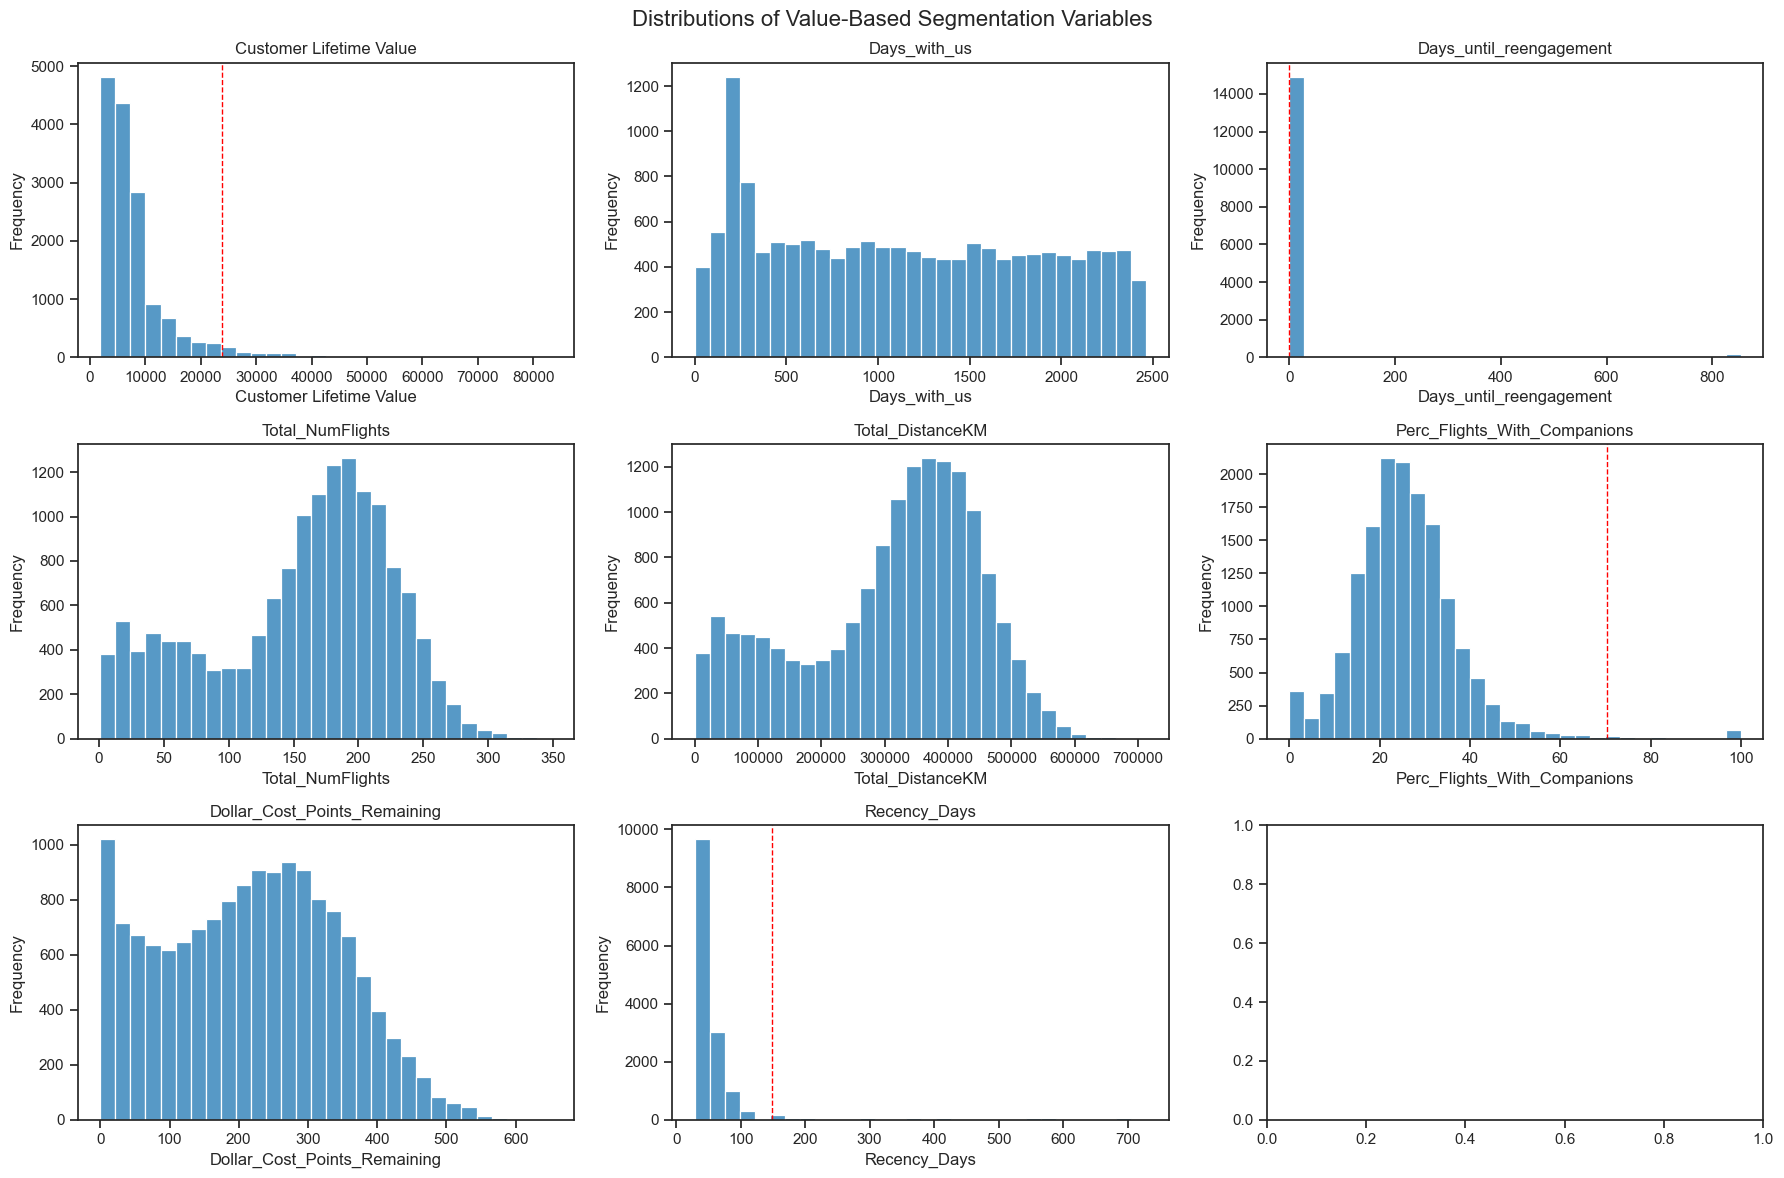

In [612]:
cols = [
    col for col in Value_Based_Segmentation_clustering.columns
    if col != "Loyalty#"
]
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, cols):

    data = Value_Based_Segmentation_clustering[col].dropna()

    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr

    # Plot histogram
    sns.histplot(data, bins=30, ax=ax)

    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)

    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Distributions of Value-Based Segmentation Variables", fontsize=16)
plt.tight_layout()
plt.show()
# ...existing code...

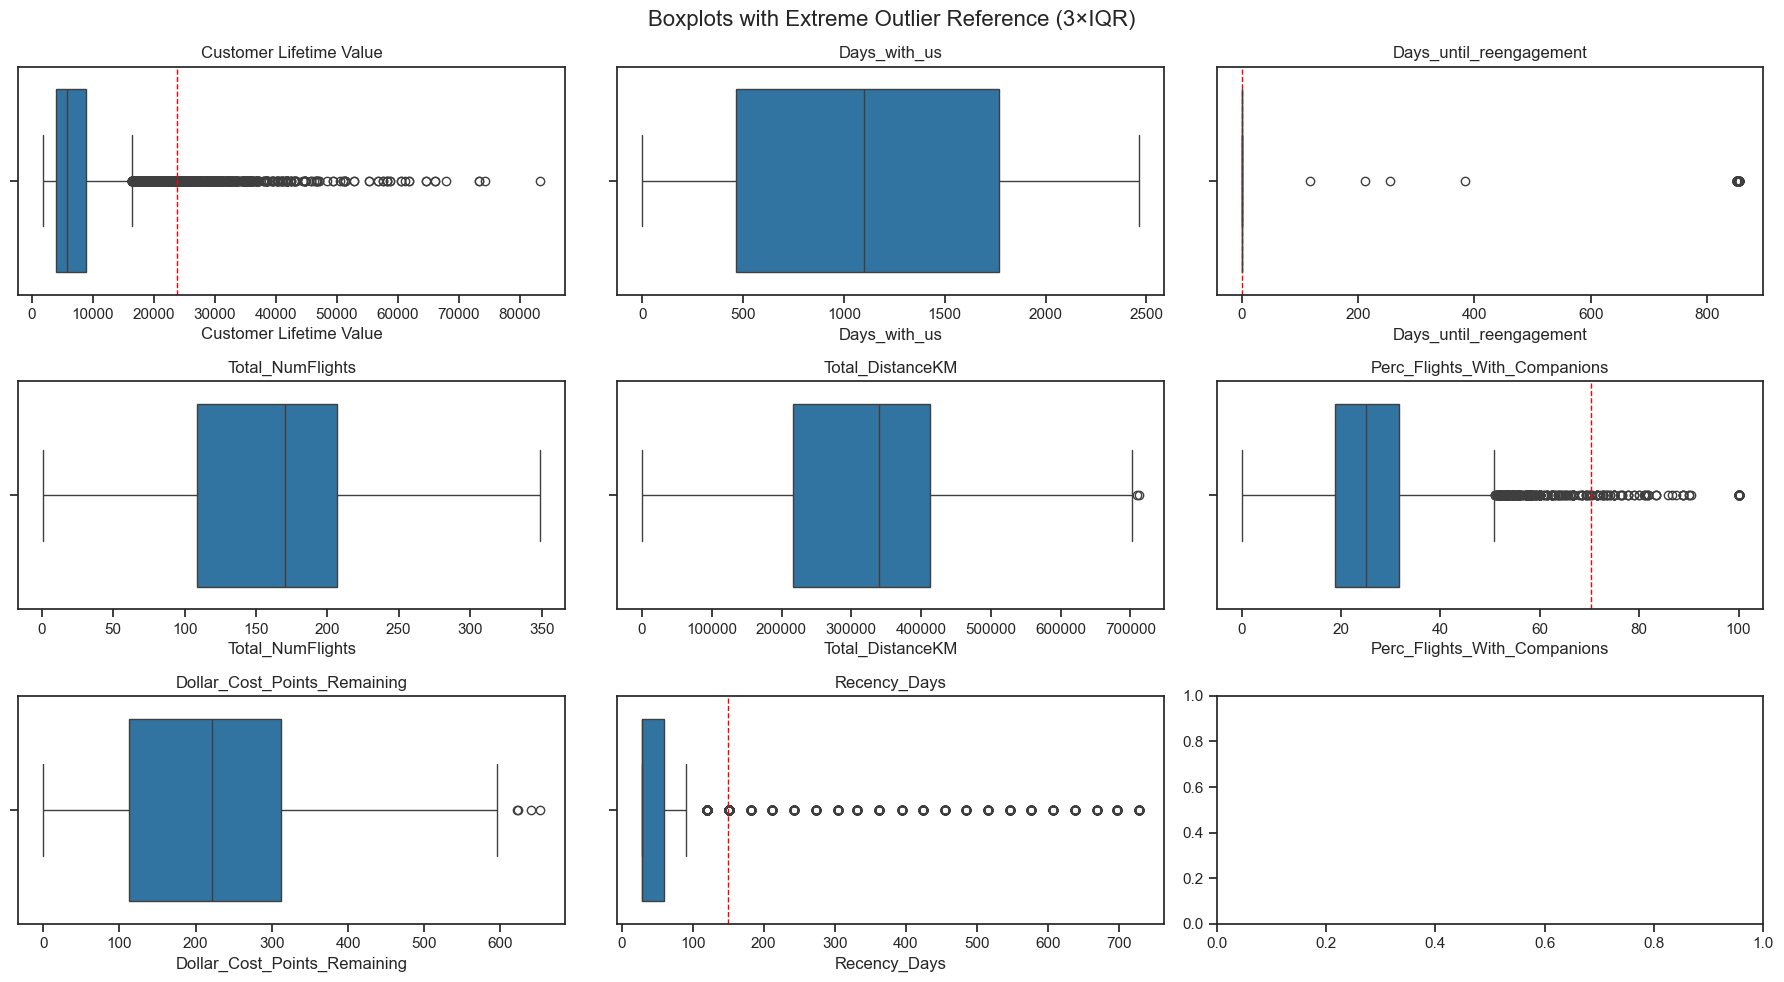

In [613]:
cols = [
    col for col in Value_Based_Segmentation_clustering.columns
    if col != "Loyalty#"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    
    data = Value_Based_Segmentation_clustering[col].dropna()
    
    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    
    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr
    
    # Boxplot
    sns.boxplot(x=data, ax=ax)
    
    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)
        
    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)
    
    ax.set_title(col)
    ax.set_xlabel(col)

plt.suptitle(
    "Boxplots with Extreme Outlier Reference (3×IQR)",
    fontsize=16
)
plt.tight_layout()
plt.show()


Overall, the graphs look acceptable. There is some right skewness, but it does not appear to be a major issue at this stage.</br></br>
The main parameters that require closer inspection are Customer Lifetime Value, Days Until, Percentage of Flights with Companions, and Recency Days Reengagement. We analyze these features one by one to understand whether the extreme values represent true outliers or meaningful customer behavior. This assessment will help decide whether they should be preserved for clustering or handled during the scaling step.

## Outliers Detection

### Customer Lifetime Value

Customer Lifetime Value is a core variable in value-based segmentation. Extremely high values may indicate highly valuable customers rather than noise, so they should not be removed without careful consideration.
To better understand the distribution, we examine the proportion of customers with a lifetime value above 60,000. This helps undertand whether these values are rare outliers or represent a meaningful segment in the data.

In [614]:
clv = Value_Based_Segmentation_clustering['Customer Lifetime Value']
Q1 = clv.quantile(0.25)
Q3 = clv.quantile(0.75)
IQR = Q3 - Q1

clv_upper_3iqr = Q3 + 3 * IQR

clv_perc_above_3iqr = (clv > clv_upper_3iqr).mean() * 100

clv_perc_above_3iqr


np.float64(3.8275610886696247)

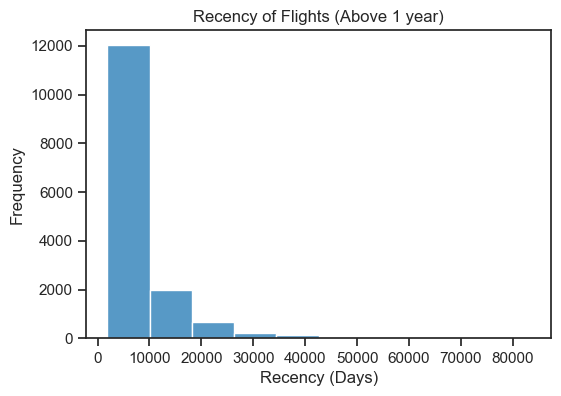

In [615]:
plt.figure(figsize=(6,4))
sns.histplot(clv[clv > clv_perc_above_3iqr], bins=10)
plt.title("Recency of Flights (Above 1 year)")
plt.xlabel("Recency (Days)")
plt.ylabel("Frequency")
plt.show()

The percentage of extreme values is very small, and since these customers remain high-value, we will apply a ceiling to limit values above three times the upper quartile. This helps reduce the impact of extremes and can potentially improve clustering results.

In [616]:
Value_Based_Segmentation_clustering['Customer Lifetime Value'] = (
    Value_Based_Segmentation_clustering['Customer Lifetime Value']
    .clip(upper=clv_upper_3iqr)
)

In [617]:
print(Value_Based_Segmentation_clustering['Customer Lifetime Value'].max() == clv_upper_3iqr)

True


### Days until reengagement

This variable contains a large number of zeros, which correspond to customers who never left the program. In this case, standard outlier detection methods such as IQR are not informative.
To better understand the behavior of this feature, we analyze its distribution after excluding active users. This allows us to focus on customers who actually disengaged and observe how reengagement time is distributed.

98.82127011456195


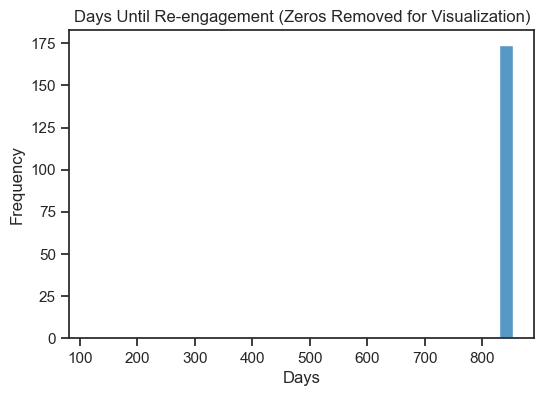

In [618]:
dur = Value_Based_Segmentation_clustering['Days_until_reengagement']

# Percentage of zeros
perc_zero = (dur == 0).mean() * 100
print(perc_zero)
plt.figure(figsize=(6,4))
sns.histplot(dur[dur > 0], bins=30)
plt.title("Days Until Re-engagement (Zeros Removed for Visualization)")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()


In [619]:
perc_800= (dur > 800).mean() * 100
print(perc_800)
print(perc_800 + perc_zero)

1.1522415734057347
99.97351168796769


A small fraction of customers (around 2%) shows extremely long re-engagement periods, in some cases exceeding 800 days. These customers typically flew with us, left the program, and rejoined after a long gap(for example due to promotion).
Although these values are extreme compared to the rest of the dataset, they reflect real customer behavior rather than noise. To avoid distorting clustering distances.

Based on this, we consider this approache: We will apply scaling methods that account for these differences and evaluate how they affect the clustering results.

### Percentage of Flights With Companions

This feature presents a situation similar to Customer Lifetime Value. While extreme values exist, they may reflect meaningful travel behavior rather than noise.
Before moving forward, it is important to examine how the data behaves at the extremes of this variable. Since this feature is essential for clustering, the decision on how to handle these values should be made carefully, balancing robustness with the need to preserve relevant customer patterns.

0.8343818290179458


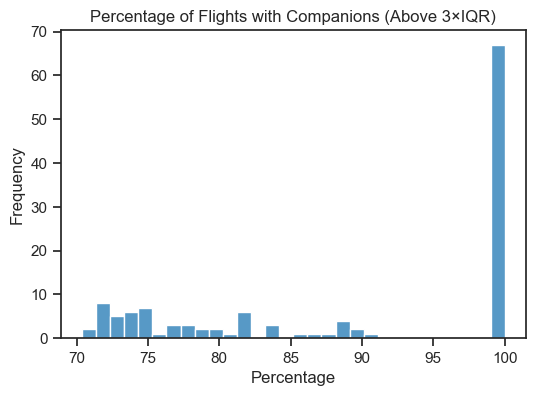

In [620]:
companions = Value_Based_Segmentation_clustering['Perc_Flights_With_Companions']
Q1 = companions.quantile(0.25)
Q3 = companions.quantile(0.75)
IQR = Q3 - Q1

companions_upper_3iqr = Q3 + 3 * IQR

companions_perc_above_3iqr = (companions > companions_upper_3iqr).mean() * 100

print(companions_perc_above_3iqr)

plt.figure(figsize=(6,4))
sns.histplot(companions[companions > companions_upper_3iqr], bins=30)
plt.title("Percentage of Flights with Companions (Above 3×IQR)")
plt.xlabel("Percentage")
plt.ylabel("Frequency")
plt.show()

Only about 1% of the records lie above the extreme threshold (and this is even if we are not taking into consideration that these are percents and scale from to 100 is crucial) these customers are still play a crucial role in the analysis. This information should therefore be kept in mind during the clustering stage, rather than removing or heavily transforming these values at this point.

### Recency Days

This situation is similar to what we observed with Customer Lifetime Value and Percentage of Flights With Companions. To proceed, it is important to examine how the data behaves at the extremes for this feature. Since it is essential for clustering, any decisions on handling extreme values should carefully balance preserving meaningful patterns with ensuring robust analysis.

In [621]:
recency = Value_Based_Segmentation_clustering['Recency_Days']
Q1 = recency.quantile(0.25)
Q3 = recency.quantile(0.75)
IQR = Q3 - Q1

recency_upper_3iqr = Q3 + 3 * IQR

recency_perc_above_3iqr = (recency > recency_upper_3iqr).mean() * 100

recency_perc_above_3iqr

np.float64(7.284285808886828)

There are quite a few observations, but if we consider typical travel behavior (most people don’t fly more than once a year for vacations) it makes sense to focus on flights occurring more than a year apart. We can then explore applying a ceiling to reduce the number of extreme values, while still capturing meaningful patterns.

3.66863121647573


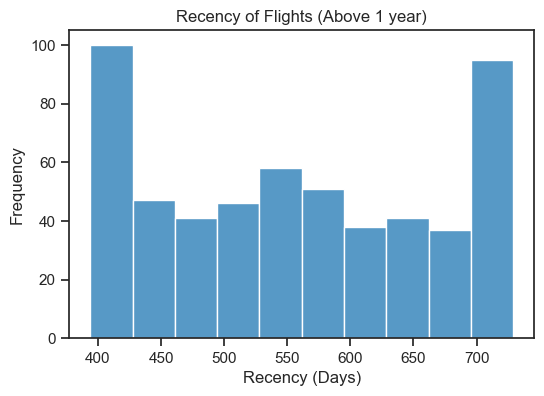

In [622]:
perc_above_365 = (recency > 365).mean() * 100
print(perc_above_365)
plt.figure(figsize=(6,4))
sns.histplot(recency[recency > 365], bins=10)
plt.title("Recency of Flights (Above 1 year)")
plt.xlabel("Recency (Days)")
plt.ylabel("Frequency")
plt.show()

Customers with long recency periods(>>3*Quartile) represent extreme values in the dataset. To limit their impact on clustering while preserving overall patterns, we can apply a ceiling and set all recency values above 365 days to 365

In [623]:
Value_Based_Segmentation_clustering['Recency_Days'] = (
    Value_Based_Segmentation_clustering['Recency_Days']
    .clip(upper=365)
)

### Visualizations after working on outliers

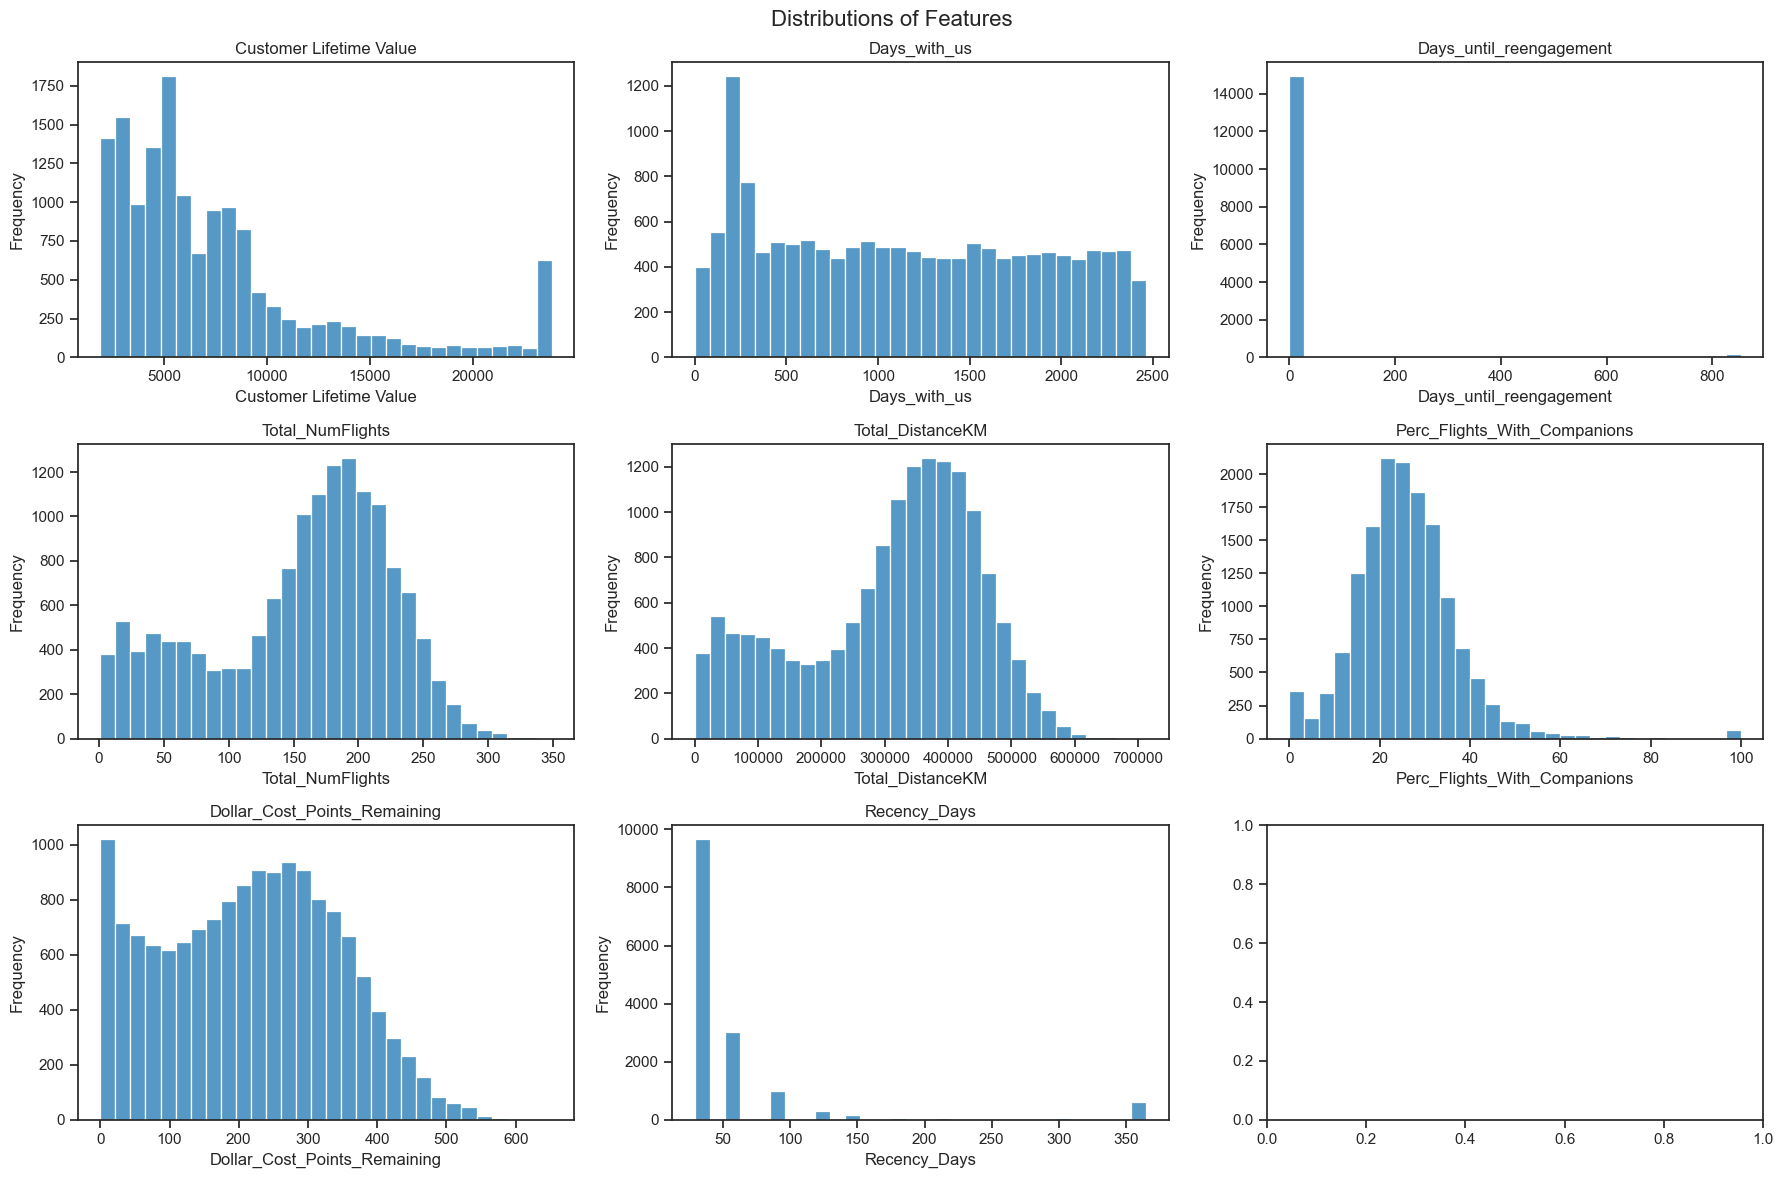

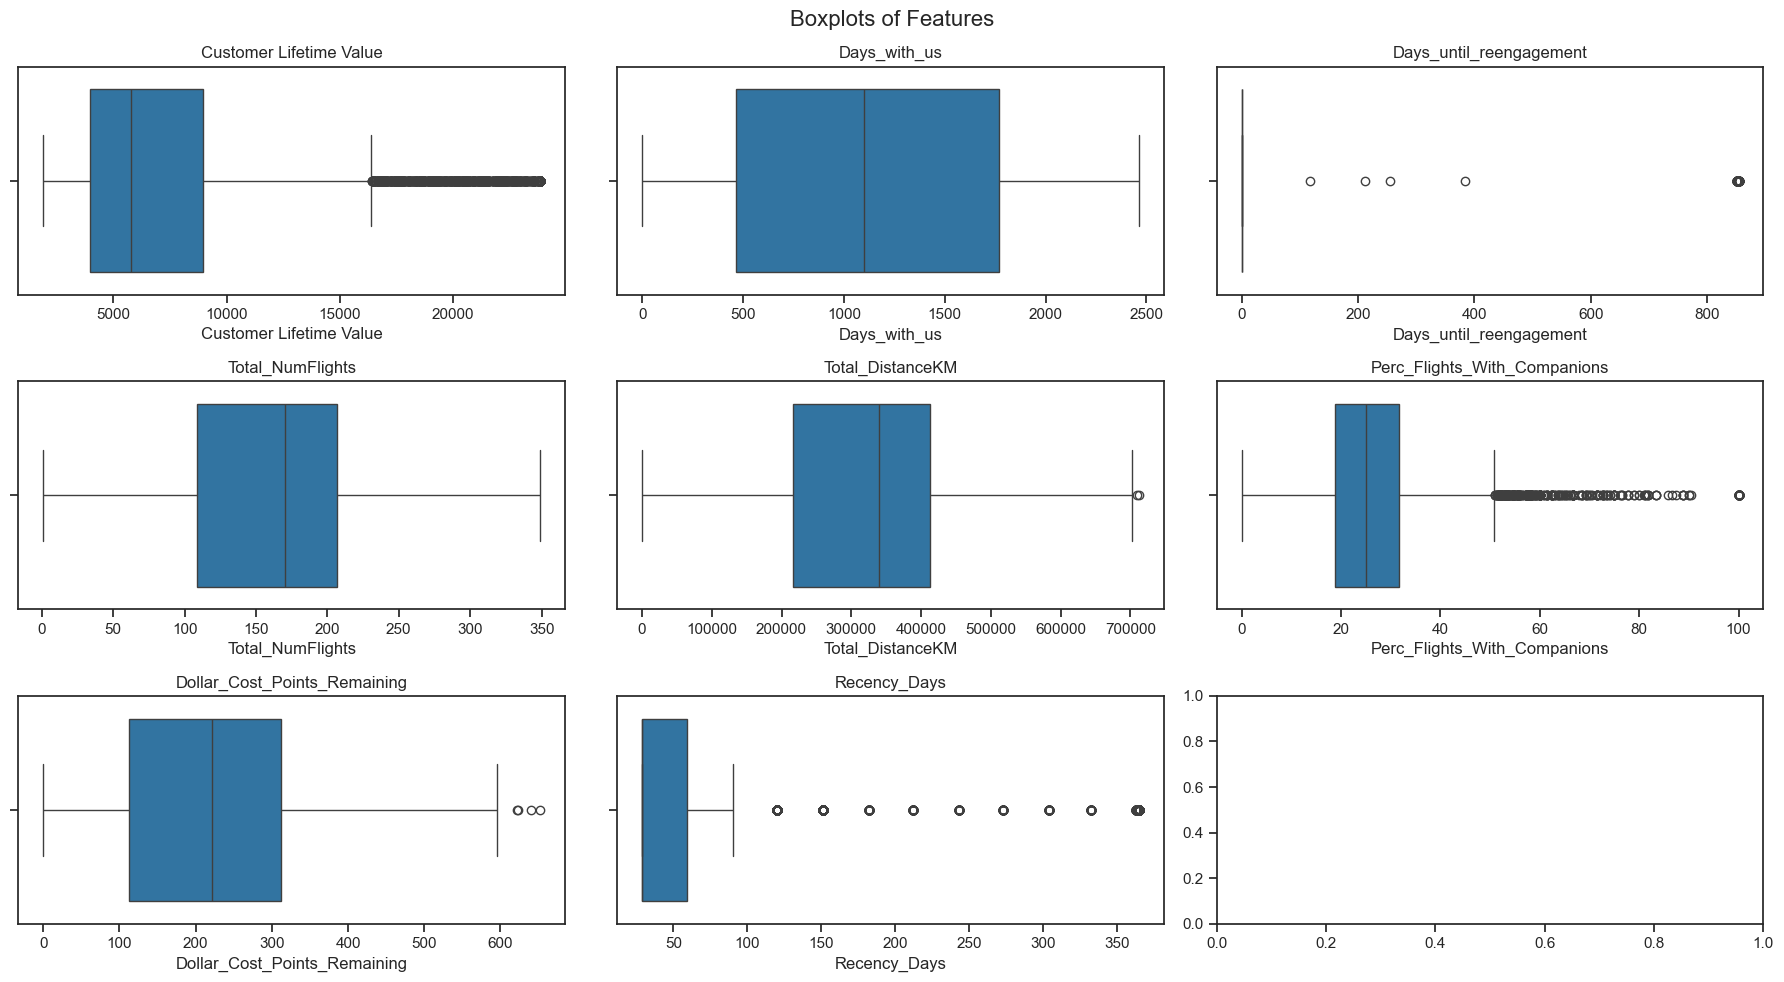

In [624]:
cols = [
    col for col in Value_Based_Segmentation_clustering.columns
    if col != "Loyalty#"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    data = Value_Based_Segmentation_clustering[col].dropna()
    
    sns.histplot(data, bins=30, ax=ax)
    
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle(
    "Distributions of Features",
    fontsize=16
)
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    data = Value_Based_Segmentation_clustering[col].dropna()
    
    sns.boxplot(x=data, ax=ax)
    
    ax.set_title(col)
    ax.set_xlabel(col)

plt.suptitle(
    "Boxplots of Features",
    fontsize=16
)
plt.tight_layout()
plt.show()


## Scaling 

We are using Robust scaler to each feature except Loyalty# since its our id and later on we will extract it before actually putting to the model so it wont influence our clustering

In [625]:

scaler = MinMaxScaler()

features_to_scale = [
    'Customer Lifetime Value',
    'Days_with_us',
    'Days_until_reengagement',
    'Total_NumFlights',
    'Total_DistanceKM',
    'Perc_Flights_With_Companions',
    'Dollar_Cost_Points_Remaining',
    'Recency_Days'
]

# preserve original data
Value_Based_Segmentation_clustering_scaled = Value_Based_Segmentation_clustering.copy()

# apply Min-Max scaling
Value_Based_Segmentation_clustering_scaled[features_to_scale] = scaler.fit_transform(
    Value_Based_Segmentation_clustering[features_to_scale]
)

Value_Based_Segmentation_clustering_scaled.head()


,Customer Lifetime Value,Days_with_us,Days_until_reengagement,Total_NumFlights,Total_DistanceKM,Perc_Flights_With_Companions,Dollar_Cost_Points_Remaining,Recency_Days
Loyalty#,,,,,,,,
480934,0.088423,0.425558,0.0,0.545977,0.697644,0.293194,0.555300,0.000000
549612,0.088444,0.416633,0.0,0.798851,0.546805,0.114695,0.253413,0.000000
429460,0.088450,0.516836,0.0,0.341954,0.322002,0.333333,0.268306,0.994048
608370,0.088450,0.869371,0.0,0.560345,0.541317,0.295918,0.341395,0.000000
530508,0.088589,0.619473,0.0,0.488506,0.514056,0.368421,0.562048,0.000000


In [626]:
Value_Based_Segmentation_clustering_scaled.describe().T


,count,mean,std,min,25%,50%,75%,max
Customer Lifetime Value,15101.0,0.260094,0.244418,0.0,0.094083,0.176408,0.320562,1.0
Days_with_us,15101.0,0.462944,0.293174,0.0,0.189047,0.445842,0.718458,1.0
Days_until_reengagement,15101.0,0.011578,0.106653,0.0,0.000000,0.000000,0.000000,1.0
Total_NumFlights,15101.0,0.443185,0.203031,0.0,0.310345,0.485632,0.591954,1.0
Total_DistanceKM,15101.0,0.433119,0.197972,0.0,0.303823,0.476485,0.578939,1.0
Perc_Flights_With_Companions,15101.0,0.258684,0.119478,0.0,0.188406,0.250000,0.316940,1.0
Dollar_Cost_Points_Remaining,15101.0,0.332125,0.195699,0.0,0.171893,0.340160,0.478644,1.0
Recency_Days,15101.0,0.094326,0.219971,0.0,0.000000,0.000000,0.089286,1.0


# Clustering

## Our Final data set for clusting

Now droping Loyalty# for clustering

In [627]:
## Value_Based_Segmentation_clustering_no_transaction_fit = Value_Based_Segmentation_clustering_no_transaction.drop(columns=['Loyalty#'])
## Value_Based_Segmentation_clustering preprocesses but not scaled
## Value_Based_Segmentation_clustering_scaled preprocesses and scaled with Loyalty# as an index
Value_Based_Segmentation_clustering['Final_Cluster'] = 'Unspecified'

classified_data = Value_Based_Segmentation_clustering[
    Value_Based_Segmentation_clustering.Final_Cluster != 'Unspecified'
]
unclassified_data = Value_Based_Segmentation_clustering[
    Value_Based_Segmentation_clustering.Final_Cluster == 'Unspecified'
]
data_for_modelling = (
    Value_Based_Segmentation_clustering_scaled
        .loc[unclassified_data.index]
)
print(data_for_modelling.describe().T)
print(data_for_modelling.head())
print(classified_data.head())
print(unclassified_data.head())
print(Value_Based_Segmentation_clustering_scaled.head())

                                count      mean       std  min       25%       50%       75%  max
Customer Lifetime Value       15101.0  0.260094  0.244418  0.0  0.094083  0.176408  0.320562  1.0
Days_with_us                  15101.0  0.462944  0.293174  0.0  0.189047  0.445842  0.718458  1.0
Days_until_reengagement       15101.0  0.011578  0.106653  0.0  0.000000  0.000000  0.000000  1.0
Total_NumFlights              15101.0  0.443185  0.203031  0.0  0.310345  0.485632  0.591954  1.0
Total_DistanceKM              15101.0  0.433119  0.197972  0.0  0.303823  0.476485  0.578939  1.0
Perc_Flights_With_Companions  15101.0  0.258684  0.119478  0.0  0.188406  0.250000  0.316940  1.0
Dollar_Cost_Points_Remaining  15101.0  0.332125  0.195699  0.0  0.171893  0.340160  0.478644  1.0
Recency_Days                  15101.0  0.094326  0.219971  0.0  0.000000  0.000000  0.089286  1.0
          Customer Lifetime Value  Days_with_us  Days_until_reengagement  Total_NumFlights  Total_DistanceKM  Perc_Fli

In [628]:
print(data_for_modelling.shape)
print(data_for_modelling.isna().sum())

(15101, 8)
Customer Lifetime Value         0
Days_with_us                    0
Days_until_reengagement         0
Total_NumFlights                0
Total_DistanceKM                0
Perc_Flights_With_Companions    0
Dollar_Cost_Points_Remaining    0
Recency_Days                    0
dtype: int64


In [629]:
data_for_modelling.var().sort_values()

Days_until_reengagement         0.011375
Perc_Flights_With_Companions    0.014275
Dollar_Cost_Points_Remaining    0.038298
Total_DistanceKM                0.039193
Total_NumFlights                0.041222
Recency_Days                    0.048387
Customer Lifetime Value         0.059740
Days_with_us                    0.085951
dtype: float64

### Datasets Overview

Different versions of the data are used to clearly separate **model fitting**, **interpretation**, and **final analysis**.

#### `Value_Based_Segmentation_clustering_no_transaction_fit`
Data of the customers who do not have any transactions.
Used to test clustering behavior without transactional information.

---

#### `classified_data`
Customers whose `Final_Cluster` is **already defined**.  
Used for final cluster profiling, interpretation, and reporting.

---

#### `unclassified_data`
Customers whose `Final_Cluster` is `"Unspecified"`.  
This is the dataset used to explore and evaluate clustering solutions.

---

#### `data_for_modelling`
**Scaled numeric data** used to fit clustering algorithms.  
Scaling is applied only for modeling, not for interpretation.

---


## Phase 2 — Ward Hierarchical Clustering (Structure Discovery)
Ward is used to explore structure only. We rely on Euclidean distance with Ward linkage to surface plausible k ranges before locking anything in.

In [658]:

# Base matrices for clustering
feature_cols = features_to_scale
X_model = data_for_modelling[feature_cols].copy()

# Helper functions for within-cluster dispersion and variance explained
def compute_ssw(X, labels):
    'Sum of squared distances within clusters.'
    X_np = X.values
    ssw = 0.0
    for lbl in np.unique(labels):
        cluster_points = X_np[labels == lbl]
        centroid = cluster_points.mean(axis=0)
        ssw += ((cluster_points - centroid) ** 2).sum()
    return ssw


def compute_r2(X, labels):
    'Proportion of variance explained by cluster assignment.'
    X_np = X.values
    sst = ((X_np - X_np.mean(axis=0)) ** 2).sum()
    ssw = compute_ssw(X, labels)
    return 1 - ssw / sst


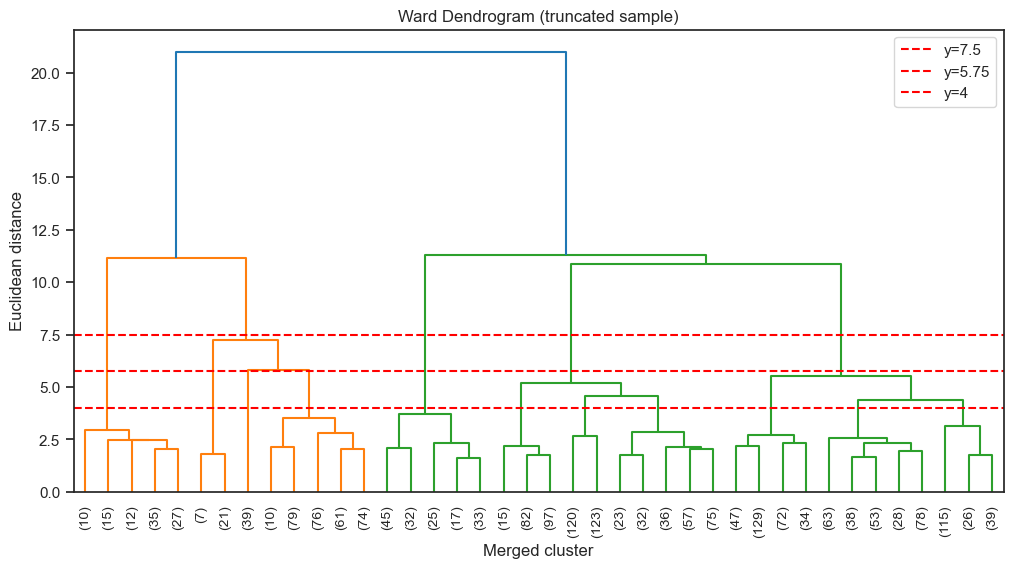

Strongest dendrogram jump: 9.708 at merge 1997
Auto candidate k range (Ward-guided): [2, 3, 4]
Final candidate k range (visual cut y=7.5): [5, 7, 11]


In [659]:

# Ward dendrogram on a manageable sample (full tree on 15k points is too heavy)
ward_sample = X_model.sample(n=min(2000, X_model.shape[0]), random_state=RANDOM_STATE)
ward_full_model = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0,
    linkage='ward',
    compute_distances=True,
)
ward_full_model.fit(ward_sample)

Y_THRESHOLD = 7.5  # visual cut to yield ~5 clusters on the truncated tree
Y_THRESHOLD_2 = 5.75  # visual cut to yield ~7 clusters on the truncated tree
Y_THRESHOLD_3 = 4  # visual cut to yield ~12 clusters on the truncated tree

plt.figure(figsize=(12, 6))
plot_dendrogram(
    ward_full_model,
    truncate_mode="lastp",
    p=40,
    leaf_rotation=90.,
    leaf_font_size=10.,
)
plt.axhline(y=Y_THRESHOLD, color='red', linestyle='--', label=f'y={Y_THRESHOLD}')
plt.axhline(y=Y_THRESHOLD_2, color='red', linestyle='--', label=f'y={Y_THRESHOLD_2}')
plt.axhline(y=Y_THRESHOLD_3, color='red', linestyle='--', label=f'y={Y_THRESHOLD_3}')

plt.legend(loc='upper right')
plt.title("Ward Dendrogram (truncated sample)")
plt.xlabel("Merged cluster")
plt.ylabel("Euclidean distance")
plt.show()

# Identify the first major vertical jump to bracket candidate k
ward_distances = ward_full_model.distances_
ward_jumps = np.diff(ward_distances)
ward_jump_idx = int(ward_jumps.argmax())
ward_jump_height = ward_jumps[ward_jump_idx]
# number of clusters just before the jump
k_at_jump = ward_sample.shape[0] - (ward_jump_idx + 1)
candidate_k_from_jump = max(2, min(12, k_at_jump))
candidate_k_range_auto = sorted(
    list(range(max(2, candidate_k_from_jump - 2), min(12, candidate_k_from_jump + 3)))
)
if not candidate_k_range_auto:
    candidate_k_range_auto = list(range(4, 8))

# Override with visually preferred ks from dendrogram cut
candidate_k_range = [5, 7, 11]

print(f"Strongest dendrogram jump: {ward_jump_height:.3f} at merge {ward_jump_idx}")
print(f"Auto candidate k range (Ward-guided): {candidate_k_range_auto}")
print(f"Final candidate k range (visual cut y={Y_THRESHOLD}): {candidate_k_range}")


**Dendrogram conclusion:** Using a visual cut at y ≈ 7.5 on the Ward tree, we carry forward candidate k values **5**, **7**, and **12** for K-Means evaluation.

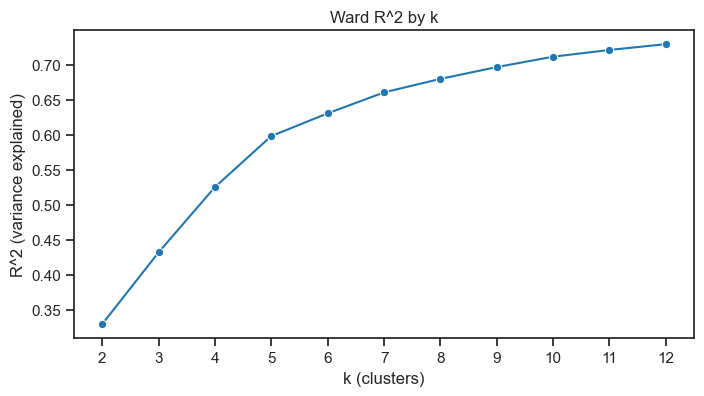

In [660]:

# Ward R^2 across k (2 to 12) to confirm structure is meaningful
ward_r2 = []
for k in range(2, 13):
    ward_k = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = ward_k.fit_predict(X_model)
    ward_r2.append({'k': k, 'r2': compute_r2(X_model, labels)})

ward_r2_df = pd.DataFrame(ward_r2)
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=ward_r2_df, x='k', y='r2', marker='o', ax=ax)
ax.set(title='Ward R^2 by k', xlabel='k (clusters)', ylabel='R^2 (variance explained)')
ax.set_xticks(range(2, 13))
plt.show()


## Phase 3 — K-Means Optimization & Selection
Run K-Means on Ward-informed candidate ks with heavy initialization, evaluate quantitatively, then choose the final model balancing inertia, R^2, silhouette, and cluster sizes.

In [661]:

def evaluate_kmeans_suite(k_values, X):
    """Train K-Means for each k and capture metrics + labels."""
    results = []
    models = {}
    labels_lookup = {}
    for k in k_values:
        model = KMeans(
            n_clusters=k,
            init='k-means++',
            n_init=30,
            random_state=RANDOM_STATE,
        )
        labels = model.fit_predict(X)
        counts = pd.Series(labels).value_counts().sort_index()
        results.append({
            'k': k,
            'inertia': model.inertia_,
            'r2': compute_r2(X, labels),
            'silhouette': silhouette_score(X, labels),
            'min_cluster_size': counts.min(),
            'max_cluster_size': counts.max(),
        })
        models[k] = model
        labels_lookup[k] = labels
    results_df = pd.DataFrame(results).sort_values('k').reset_index(drop=True)
    return results_df, models, labels_lookup

kmeans_results, kmeans_models, kmeans_labels = evaluate_kmeans_suite(candidate_k_range, X_model)
kmeans_results


,k,inertia,r2,silhouette,min_cluster_size,max_cluster_size
0,5,1908.926433,0.626466,0.285021,826,5006
1,7,1604.804581,0.685978,0.262025,174,4077
2,11,1275.507437,0.750413,0.214917,174,2254


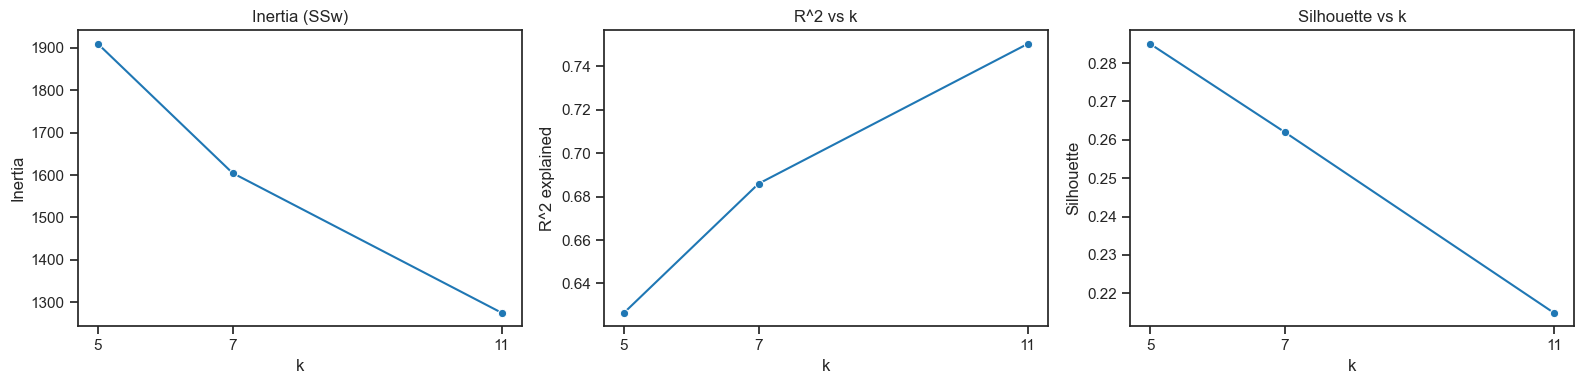

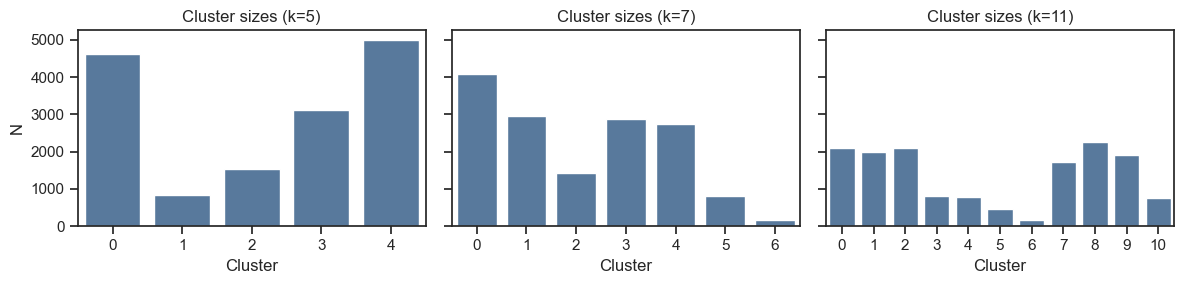

In [662]:

# Quantitative diagnostics across candidate k
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ax1, ax2, ax3 = axes
sns.lineplot(data=kmeans_results, x='k', y='inertia', marker='o', ax=ax1)
ax1.set(title='Inertia (SSw)', xlabel='k', ylabel='Inertia')
ax1.set_xticks(kmeans_results.k)

sns.lineplot(data=kmeans_results, x='k', y='r2', marker='o', ax=ax2)
ax2.set(title='R^2 vs k', xlabel='k', ylabel='R^2 explained')
ax2.set_xticks(kmeans_results.k)

sns.lineplot(data=kmeans_results, x='k', y='silhouette', marker='o', ax=ax3)
ax3.set(title='Silhouette vs k', xlabel='k', ylabel='Silhouette')
ax3.set_xticks(kmeans_results.k)
plt.tight_layout()
plt.show()

# Cluster size distributions per k
fig, axes = plt.subplots(1, len(candidate_k_range), figsize=(4 * len(candidate_k_range), 3), sharey=True)
if len(candidate_k_range) == 1:
    axes = [axes]
for ax, k in zip(axes, candidate_k_range):
    counts = pd.Series(kmeans_labels[k]).value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, color='#4C78A8')
    ax.set_title(f'Cluster sizes (k={k})')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('N')
plt.tight_layout()
plt.show()


UMAP for k=5


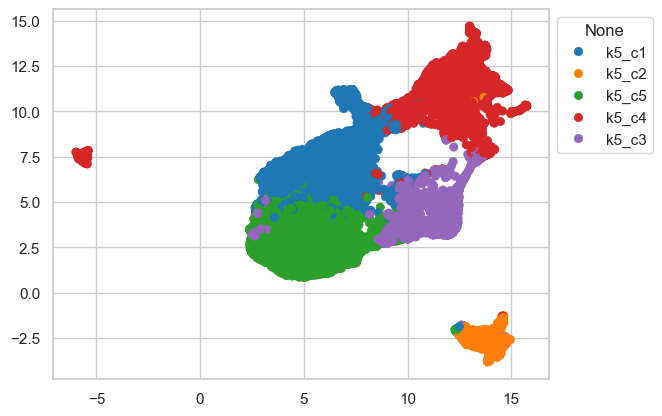

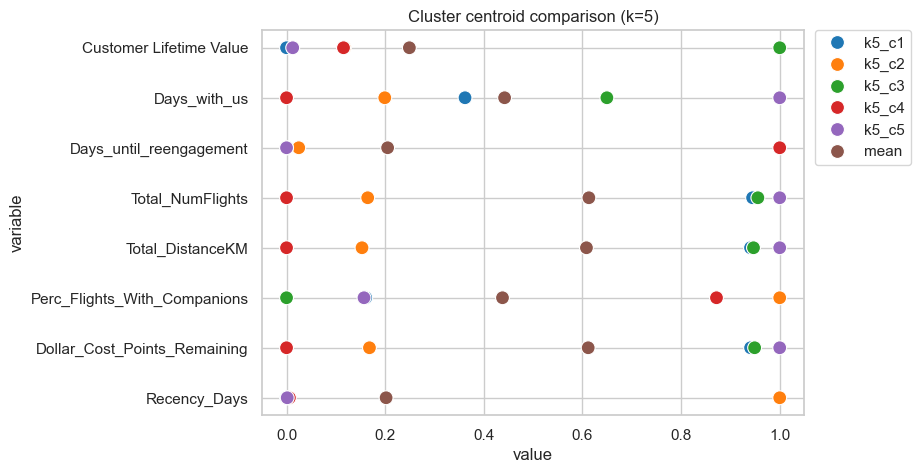

UMAP for k=7


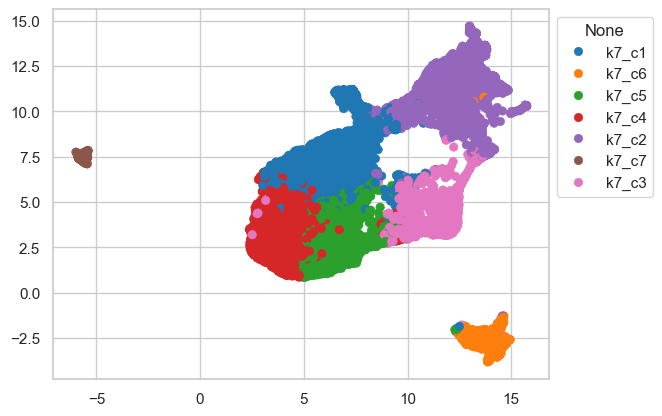

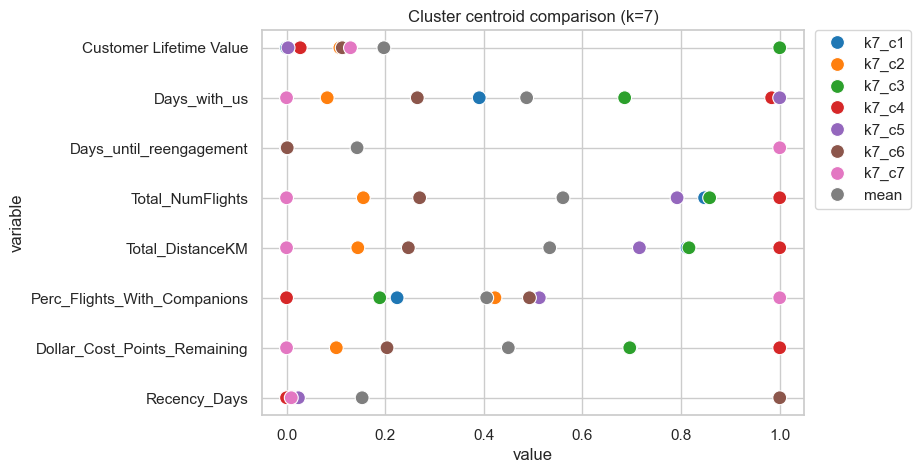

UMAP for k=11


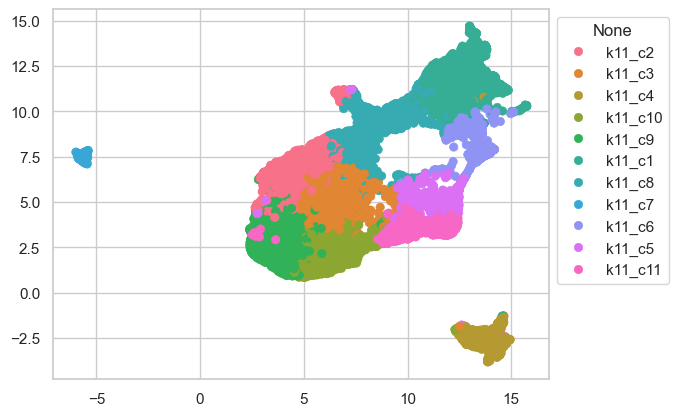

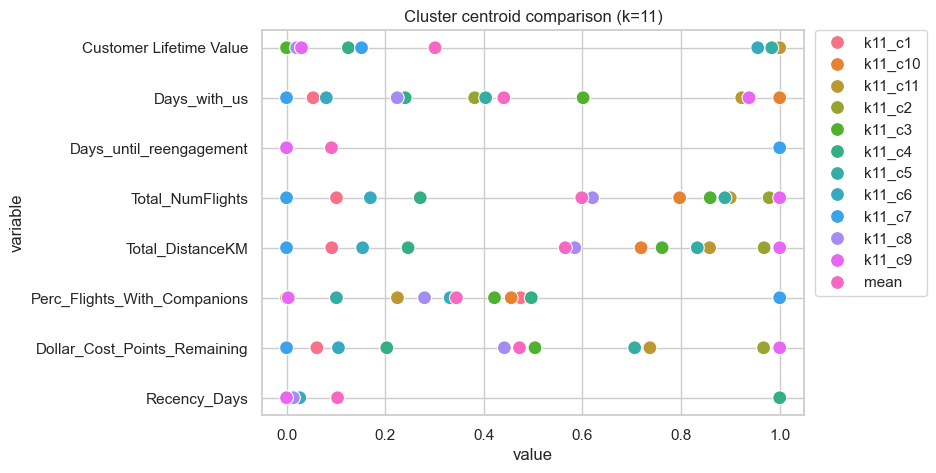

In [682]:

# Visual diagnostics per candidate k (UMAP + centroid comparison)
# Uses helper plots from utils_clustering
umap_global = umap.UMAP(n_neighbors=15, min_dist=0.05, random_state=RANDOM_STATE)
umap_embedding_global = umap_global.fit_transform(X_model)

for k in candidate_k_range:
    labels = pd.Series(kmeans_labels[k], index=X_model.index)
    label_names = labels.apply(lambda c: f"k{k}_c{c+1}")
    print(f"UMAP for k={k}")
    visualize_dimensionality_reduction(umap_embedding_global, label_names)

    centroids_df = (
        X_model.assign(cluster=label_names)
        .groupby('cluster')[feature_cols]
        .mean()
        .reset_index()
    )
    plt.figure(figsize=(7, 5))
    plot_comparing_avr_clusters(centroids_df, 'cluster')
    plt.title(f'Cluster centroid comparison (k={k})')
    plt.show()


In [687]:

# Selection logic: prefer high silhouette, diminishing inertia/R^2 gains, and non-pathological sizes
manual_final_k = 7  # Set to 5/7/12 to override automatic choice

kmeans_results['inertia_drop_pct'] = (
    kmeans_results['inertia'].shift(1) - kmeans_results['inertia']
) / kmeans_results['inertia'].shift(1)
kmeans_results['r2_gain'] = kmeans_results['r2'].diff()

best_sil = kmeans_results['silhouette'].max()
sil_guard = kmeans_results[kmeans_results['silhouette'] >= best_sil - 0.02]
elbow_guard = kmeans_results[
    (kmeans_results['inertia_drop_pct'] < 0.15) & (kmeans_results['r2_gain'] < 0.03)
]

if not elbow_guard.empty:
    candidate_final = pd.merge(sil_guard[['k']], elbow_guard[['k']], on='k')
else:
    candidate_final = sil_guard[['k']]

if manual_final_k:
    final_k = int(manual_final_k)
elif candidate_final.empty:
    final_k = int(kmeans_results.sort_values('silhouette', ascending=False).iloc[0]['k'])
else:
    final_k = int(candidate_final['k'].min())

final_kmeans_model = kmeans_models[final_k]
final_k_labels = kmeans_labels[final_k]
final_cluster_names = pd.Series(final_k_labels, index=X_model.index).apply(lambda c: f"Cluster_{c+1}")

print(f"Selected final k: {final_k}")
print(kmeans_results[kmeans_results.k == final_k])


Selected final k: 7
   k      inertia        r2  silhouette  min_cluster_size  max_cluster_size  inertia_drop_pct   r2_gain
1  7  1604.804581  0.685978    0.262025               174              4077          0.159316  0.059512


**Manual override option:** set `manual_final_k` in the cell above (5, 7, or 12) after reviewing metrics/UMAP plots to force the final choice while keeping the math diagnostics in place.

Cluster centroid table (scaled space):


,Customer Lifetime Value,Days_with_us,Days_until_reengagement,Total_NumFlights,Total_DistanceKM,Perc_Flights_With_Companions,Dollar_Cost_Points_Remaining,Recency_Days
0,0.177529,0.335247,-8.500145e-17,0.527949,0.516741,0.254163,0.399900,0.044130
1,0.246184,0.118661,9.194034e-17,0.153890,0.150261,0.267273,0.109922,0.049577
2,0.814020,0.543046,4.163336e-17,0.533175,0.518470,0.251794,0.398746,0.046084
3,0.195210,0.753386,9.367507e-17,0.609717,0.619095,0.239369,0.545952,0.034748
4,0.178907,0.763066,1.023487e-16,0.497241,0.462921,0.273161,0.278796,0.056641
5,0.249313,0.247219,1.380111e-03,0.215528,0.206407,0.271965,0.159772,0.933591
6,0.259938,0.060598,9.983109e-01,0.069758,0.070933,0.305690,0.060827,0.043428


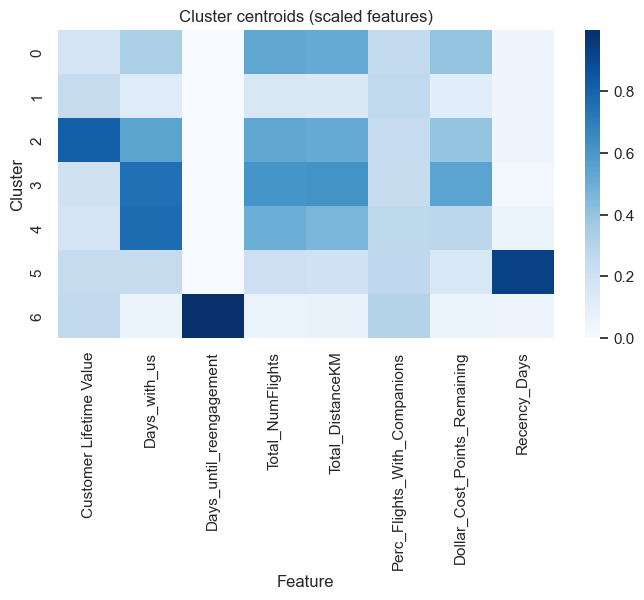

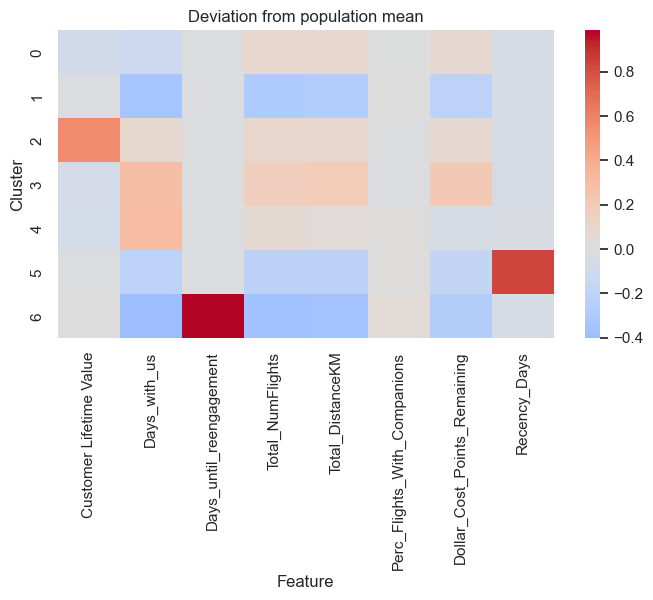

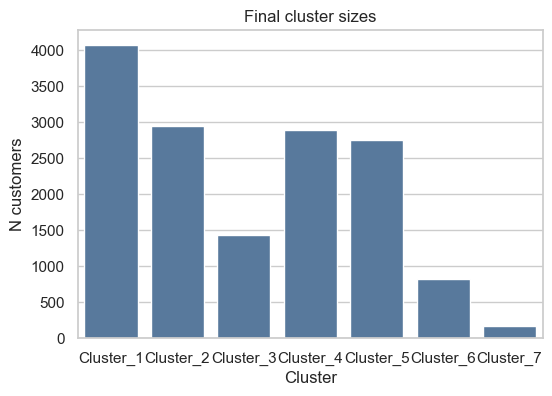

In [688]:

# Cluster centroids and heatmaps
cluster_centroids = pd.DataFrame(
    final_kmeans_model.cluster_centers_, columns=feature_cols
)
population_mean = X_model.mean()
centroid_diff = cluster_centroids - population_mean

print("Cluster centroid table (scaled space):")
display(cluster_centroids)

plt.figure(figsize=(8, 4))
sns.heatmap(cluster_centroids, cmap='Blues', annot=False, cbar=True)
plt.title('Cluster centroids (scaled features)')
plt.ylabel('Cluster')
plt.xlabel('Feature')
plt.show()

plt.figure(figsize=(8, 4))
sns.heatmap(centroid_diff, cmap='coolwarm', center=0, annot=False)
plt.title('Deviation from population mean')
plt.ylabel('Cluster')
plt.xlabel('Feature')
plt.show()

size_distribution = final_cluster_names.value_counts().sort_index()
plt.figure(figsize=(6, 4))
sns.barplot(x=size_distribution.index, y=size_distribution.values, color='#4C78A8')
plt.title('Final cluster sizes')
plt.xlabel('Cluster')
plt.ylabel('N customers')
plt.show()


## Phase 4 — Ward vs K-Means Comparison
Cross-check structural consistency between Ward (same k) and the selected K-Means solution.

In [693]:

ward_same_k = AgglomerativeClustering(n_clusters=final_k, linkage='ward')
ward_labels_same_k = ward_same_k.fit_predict(X_model)

ward_vs_kmeans = pd.crosstab(
    pd.Series(ward_labels_same_k, name='Ward'),
    pd.Series(final_k_labels, name='K-Means'),
    normalize='index'
)
print('Ward vs K-Means label agreement (row-normalized):')
display(ward_vs_kmeans)

# Identify high-agreement pairs to lock as core structure
best_k_for_ward = ward_vs_kmeans.idxmax(axis=1)
best_score = ward_vs_kmeans.max(axis=1)
high_agreement_k = best_k_for_ward[best_score >= 0.85].unique()
robust_clusters = [f"Cluster_{k+1}" for k in high_agreement_k]
print(f"High-agreement (>=0.85) K-Means clusters from Ward mapping: {robust_clusters}")

ward_centroids = (
    X_model.assign(Ward=ward_labels_same_k)
    .groupby('Ward')[feature_cols]
    .mean()
)
print('Ward centroid profiles (scaled):')
display(ward_centroids)


Ward vs K-Means label agreement (row-normalized):


K-Means,0,1,2,3,4,5,6
Ward,,,,,,,
0,0.006990,0.980500,0.008462,0.000000,0.000000,0.004047,0.0
1,0.168923,0.000000,0.002256,0.704456,0.124365,0.000000,0.0
2,0.164731,0.001408,0.013728,0.047166,0.771911,0.001056,0.0
3,0.079694,0.010917,0.743450,0.120633,0.045306,0.000000,0.0
4,0.895649,0.080076,0.001261,0.011980,0.010088,0.000946,0.0
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
6,0.004890,0.006112,0.003667,0.000000,0.000000,0.985330,0.0


High-agreement (>=0.85) K-Means clusters from Ward mapping: ['Cluster_2', 'Cluster_1', 'Cluster_7', 'Cluster_6']
Ward centroid profiles (scaled):


,Customer Lifetime Value,Days_with_us,Days_until_reengagement,Total_NumFlights,Total_DistanceKM,Perc_Flights_With_Companions,Dollar_Cost_Points_Remaining,Recency_Days
Ward,,,,,,,,
0,0.254387,0.111250,0.000000,0.139749,0.135512,0.268094,0.101086,0.051960
1,0.173066,0.698815,0.000000,0.615755,0.612583,0.236665,0.524680,0.031203
2,0.169832,0.714594,0.000000,0.485015,0.461448,0.273598,0.291721,0.065046
3,0.729013,0.554030,0.000000,0.538799,0.528772,0.252959,0.412917,0.038850
4,0.175948,0.300188,0.000000,0.496279,0.484905,0.259018,0.363704,0.045524
5,0.259938,0.060598,0.998311,0.069758,0.070933,0.305690,0.060827,0.043428
6,0.245931,0.247749,0.001389,0.217463,0.207633,0.272603,0.159723,0.934749


## Ward vs K-Means Agreement and Centroid Interpretation — Joint Conclusion

The Ward–K-Means agreement matrix shows **strong structural consistency** between the two clustering methods.  
Four Ward clusters exhibit **near one-to-one correspondence** with K-Means clusters, indicating highly stable value segments:

- **Ward 0 → K-Means 1 (98.1%)**
- **Ward 4 → K-Means 0 (89.6%)**
- **Ward 5 → K-Means 6 (100%)**
- **Ward 6 → K-Means 5 (98.5%)**

These clusters are robust across algorithms and represent **clear value-based behaviors**.

Centroid profiles confirm this stability.  
In particular:

- **Ward Cluster 3** is the **dominant value segment**, with the **highest Customer Lifetime Value (0.73)**, high activity (**Total_NumFlights = 0.54**, **Total_DistanceKM = 0.53**), and long tenure (**Days_with_us = 0.55**). This cluster represents **core VIP customers** and should be prioritized for retention and premium strategies.

- **Ward Cluster 5** is an **extreme low-engagement segment**, characterized by an almost maximal **Days_until_reengagement (0.998)** and minimal activity (**Total_NumFlights = 0.07**, **Total_DistanceKM = 0.07**). The perfect agreement with K-Means (100%) indicates a structurally isolated group of **dormant or lost customers**, suitable for reactivation or exclusion from active campaigns.

- **Ward Cluster 6** shows **very high recency (0.93)** combined with moderate historical value (**CLV = 0.25**), signaling **previously valuable but currently inactive customers**. This explains its strong algorithmic agreement and supports treating it as a **churn-risk segment requiring special handling**.

Partial disagreement appears for **Ward Clusters 1 and 3**, where Ward Cluster 1 maps mainly to **K-Means 3 (70.4%)** but with notable spillover into other clusters, and Ward Cluster 3 splits partially despite its high value. These patterns align with centroid similarities across **Clusters 1, 2, and 4**, which share medium activity and low CLV (≈0.17–0.18), suggesting **borderline or transitional value behavior** rather than distinct economic profiles.

Overall, the combined evidence supports:
- **K-Means as a valid final clustering solution**
- **Ward clustering as structural validation**
- Explicit identification of **core, VIP, dormant, and churn-risk segments**
- Justification for marking parts of Clusters 1, 2, and 4 as **ambiguous or “leftover” customers** for secondary analysis

This joint analysis confirms that the segmentation captures genuine economic structure rather than algorithmic artifacts.



## Phase 5 — Core Clusters vs Leftovers
**Ward vs K-Means Agreement and Centroid Interpretation — Joint Conclusion**


Core vs Leftover counts:
Cluster_1    4077
Leftover     4076
Cluster_2    2948
Cluster_4    1239
Cluster_5    1030
Cluster_6     823
Cluster_3     734
Cluster_7     174
Name: count, dtype: int64
Leftover rate per cluster:
Cluster
Cluster_1    0.000000
Cluster_2    0.000000
Cluster_3    0.489924
Cluster_4    0.571429
Cluster_5    0.625318
Cluster_6    0.000000
Cluster_7    0.000000
Name: core, dtype: float64


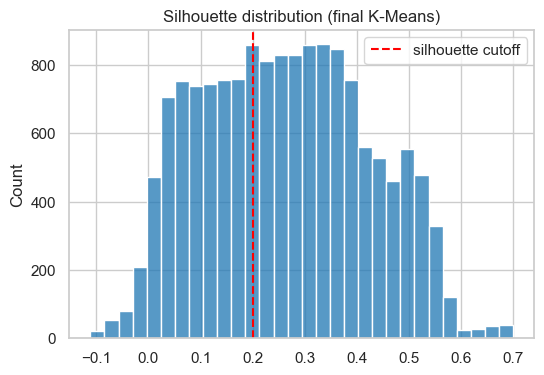

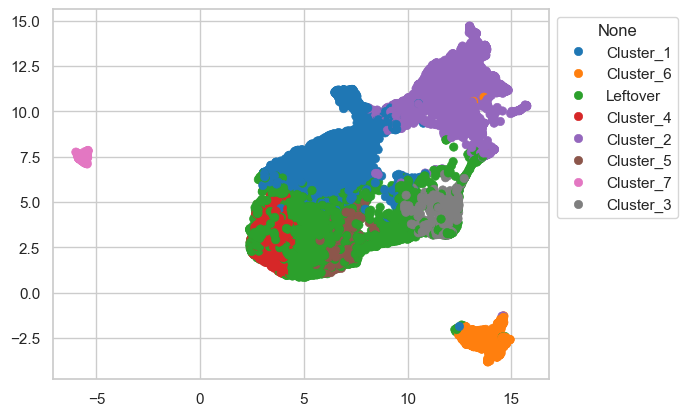

In [696]:

    # Core vs Leftovers using margin/ratio + per-cluster thresholds
    silhouette_vals = silhouette_samples(X_model, final_k_labels)

    centers = final_kmeans_model.cluster_centers_
    X_np = X_model.values
    # distance matrix: rows=obs, cols=clusters
    dist_matrix = ((X_np[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2) ** 0.5
    dist1 = dist_matrix.min(axis=1)
    best_cluster = dist_matrix.argmin(axis=1)

    # second-closest distance
    dist_matrix_sorted = np.sort(dist_matrix, axis=1)
    dist2 = dist_matrix_sorted[:, 1]

    margin = dist2 - dist1
    ratio = dist1 / dist2

    # Per-cluster thresholds
    dist1_cutoff = {}
    margin_cutoff = {}
    for c in np.unique(best_cluster):
        mask = best_cluster == c
        dist1_cutoff[c] = np.percentile(dist1[mask], 80)
        margin_cutoff[c] = np.percentile(margin[mask], 50)

    silhouette_cutoff = 0.20
    ratio_cutoff = 0.90

    # Auto-lock clusters with strong Ward↔K-Means agreement; can override manually
    try:
        robust_clusters
    except NameError:
        robust_clusters = []

    manual_core_clusters = []  # e.g., ['Cluster_5'] to forcefully keep a visually pure group
    manual_core_ids = []       # e.g., specific Loyalty# values to keep as core

    preferred_core_clusters = set(robust_clusters) | set(manual_core_clusters)

    core_flags = []
    leftover_reasons = []
    for i, c in enumerate(best_cluster):
        c_name = f"Cluster_{c+1}"
        rule1 = dist1[i] <= dist1_cutoff[c]
        rule2 = (margin[i] >= margin_cutoff[c]) or (ratio[i] <= ratio_cutoff)
        rule3 = silhouette_vals[i] >= silhouette_cutoff

        core = rule1 and rule2 and rule3
        reasons = []
        if not core:
            if not rule1:
                reasons.append('far_from_centroid')
            if not rule2:
                reasons.append('near_boundary')
            if not rule3:
                reasons.append('low_silhouette')

        # Keep preferred clusters/ids as core regardless of rules
        if (c_name in preferred_core_clusters) or (X_model.index[i] in manual_core_ids):
            core = True
            reasons = []

        core_flags.append(core)
        leftover_reasons.append(','.join(reasons) if reasons else '')

    core_assignments = pd.Series(
        [f"Cluster_{c+1}" if core else 'Leftover' for c, core in zip(best_cluster, core_flags)],
        index=X_model.index,
    )

    metrics_df = pd.DataFrame({
        'Cluster': [f"Cluster_{c+1}" for c in best_cluster],
        'dist1': dist1,
        'dist2': dist2,
        'margin': margin,
        'ratio': ratio,
        'silhouette': silhouette_vals,
        'core_flag': core_flags,
        'leftover_reason': leftover_reasons,
        'Final_Cluster': core_assignments.values,
    }, index=X_model.index)

    print('Core vs Leftover counts:')
    print(core_assignments.value_counts())
    print('Leftover rate per cluster:')
    leftover_rate = (
        metrics_df.assign(core=core_flags)
        .groupby('Cluster')['core']
        .apply(lambda s: 1 - s.mean())
    )
    print(leftover_rate)

    plt.figure(figsize=(6, 4))
    sns.histplot(silhouette_vals, bins=30)
    plt.axvline(silhouette_cutoff, color='red', linestyle='--', label='silhouette cutoff')
    plt.title('Silhouette distribution (final K-Means)')
    plt.legend()
    plt.show()

    visualize_dimensionality_reduction(umap_embedding, core_assignments)

## Phase 6 — Secondary Analysis on Leftovers Only
Apply density-based methods (DBSCAN, Mean Shift) to leftovers to see if any dense micro-groups can be recovered.

In [697]:

leftovers = X_model[core_assignments == 'Leftover']
recovered_leftover_labels = pd.Series('Unclassified', index=leftovers.index)

if leftovers.shape[0] > 0:
    dbscan = DBSCAN(eps=0.15, min_samples=30)
    db_labels = dbscan.fit_predict(leftovers)
    db_series = pd.Series(db_labels, index=leftovers.index)
    for lbl, count in db_series.value_counts().items():
        if lbl == -1 or count < 25:
            continue
        recovered_leftover_labels.loc[db_series == lbl] = f'DBSCAN_{lbl}'

    bandwidth = estimate_bandwidth(leftovers, quantile=0.2, n_samples=min(1000, leftovers.shape[0]))
    if bandwidth > 0:
        meanshift = MeanShift(bandwidth=bandwidth, bin_seeding=True)
        ms_labels = meanshift.fit_predict(leftovers)
        ms_series = pd.Series(ms_labels, index=leftovers.index)
        for lbl, count in ms_series.value_counts().items():
            if count < 25:
                continue
            target_mask = (recovered_leftover_labels == 'Unclassified') & (ms_series == lbl)
            recovered_leftover_labels.loc[target_mask] = f'MeanShift_{lbl}'

print(recovered_leftover_labels.value_counts())


DBSCAN_0       2208
MeanShift_0    1642
MeanShift_2     154
MeanShift_1      72
Name: count, dtype: int64


## Phase 7 — Final Label Consolidation
Merge core K-Means clusters with any recovered leftover groups and keep an explicit Unclassified pool.

In [678]:

final_labels = core_assignments.replace({'Leftover': 'Unclassified'}).copy()
final_labels.name = 'Final_Cluster'

if not recovered_leftover_labels.empty:
    final_labels.update(recovered_leftover_labels)

# Attach diagnostics back to the main dataframe
metrics_df_with_final = metrics_df.copy()
metrics_df_with_final['Final_Cluster'] = final_labels.loc[metrics_df_with_final.index]

Value_Based_Segmentation_clustering['Final_Cluster'] = 'Unclassified'
Value_Based_Segmentation_clustering.loc[metrics_df_with_final.index, 'Final_Cluster'] = metrics_df_with_final['Final_Cluster']

diag_cols = ['dist1', 'dist2', 'margin', 'ratio', 'silhouette', 'core_flag', 'leftover_reason']
for col in diag_cols:
    Value_Based_Segmentation_clustering[col] = None
    Value_Based_Segmentation_clustering.loc[metrics_df_with_final.index, col] = metrics_df_with_final[col]

print('Final cluster counts:')
print(final_labels.value_counts())

size_value_matrix = Value_Based_Segmentation_clustering.join(final_labels).groupby('Final_Cluster')[
    ['Customer Lifetime Value']
].agg(['count', 'mean']).rename(columns={'count': 'n', 'mean': 'avg_clv'})
print('Size–Value matrix (count, avg CLV):')
display(size_value_matrix)


Final cluster counts:
Final_Cluster
MeanShift_0    3077
Cluster_5      2710
DBSCAN_0       2494
Cluster_1      2303
Cluster_4      1913
MeanShift_1     746
DBSCAN_1        633
Cluster_3       495
Cluster_2       392
MeanShift_2     129
DBSCAN_5         68
DBSCAN_3         48
DBSCAN_2         48
DBSCAN_4         45
Name: count, dtype: int64


ValueError: columns overlap but no suffix specified: Index(['Final_Cluster'], dtype='object')

## Phase 8 — Post-Hoc Validation (Random Forest Classifier)
Train a classifier on the final labels to check learnability and feature importance.

In [ ]:

rf_encoder = LabelEncoder()
y_encoded = rf_encoder.fit_transform(final_labels)
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_encoded, test_size=0.25, random_state=RANDOM_STATE, stratify=y_encoded
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced_subsample',
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Random Forest accuracy: {rf_acc:.3f}")
print('Classification report:')
print(classification_report(y_test, rf_pred, target_names=rf_encoder.classes_))

cm = confusion_matrix(y_test, rf_pred, normalize='true')
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=rf_encoder.classes_, yticklabels=rf_encoder.classes_)
plt.title('Confusion matrix (normalized)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

feature_importances = pd.Series(rf.feature_importances_, index=X_model.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=feature_importances.values, y=feature_importances.index, color='#4C78A8')
plt.title('Feature importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


## Phase 9 — Final Validation & Reporting
Key visuals and tables to keep: dendrogram (Ward), elbow/R^2/silhouette curves, UMAP with final labels, heatmaps vs population mean, cluster size bar chart, feature importances, centroid table, size–value matrix, and classified vs unclassified counts.

In [ ]:

# Final reporting snippets (reuse previously computed objects)
# Dendrogram already generated above on Ward sample

# Elbow / R^2 / Silhouette already plotted in Phase 3

# UMAP with final labels
visualize_dimensionality_reduction(umap_embedding, final_labels)

# Heatmap vs population mean
plt.figure(figsize=(8, 4))
sns.heatmap(centroid_diff, cmap='coolwarm', center=0, annot=False)
plt.title('Cluster vs population mean (scaled)')
plt.ylabel('Cluster')
plt.xlabel('Feature')
plt.show()

# Cluster size bar chart
size_distribution = final_labels.value_counts().sort_values(ascending=False)
plt.figure(figsize=(6, 4))
sns.barplot(x=size_distribution.values, y=size_distribution.index, color='#4C78A8')
plt.title('Final cluster size balance')
plt.xlabel('N customers')
plt.ylabel('Cluster')
plt.show()

# Silhouette distribution for the final solution
plt.figure(figsize=(6, 4))
sns.histplot(silhouette_vals, bins=30)
plt.axvline(silhouette_threshold, color='red', linestyle='--')
plt.title('Silhouette distribution (final model)')
plt.xlabel('Silhouette value')
plt.ylabel('Count')
plt.show()
